In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import qmc

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
scale = 1# 1000 ** 2

In [6]:
E = 2.0e9 / scale  # Elastic modulus, N/m^2
NU = 0.29  # Poisson's ratio
G = 0.775e9 / scale  # Shear modulus, N/m^2
d31 = 2.2e-11  # Piezoelectric strain coefficients, C/N
d33 = -3.0e-11

rel_permittivity = 12

permittivity_free_space = 8.854187817620e-12 / 1  # F/m
C11 = E / (1 - NU**2)
C12 = NU * C11

In [7]:
# WIDTH = 100e-3
# HEIGHT = 1e-3
WIDTH = 100e-3
HEIGHT = 1e-3
H2 = HEIGHT/2
CENTER = H2

In [8]:
# Y_TOP = HEIGHT
# Y_BOTTOM = 0
Y_TOP = HEIGHT
Y_BOTTOM = 0

In [9]:
C11, C12

(2183644502.6749644, 633256905.7757397)

In [10]:
c2d = np.array([[C11, C12, 0], [C12, C11, 0], [0, 0, G]])
pze_D = np.array([[0, d31], [0, d33], [0, 0]])

In [11]:
pze_E = c2d @ pze_D
D_const_stress = np.array([[rel_permittivity, 0],
                           [0, rel_permittivity]]) * permittivity_free_space

In [12]:
D_const_strain = D_const_stress - pze_D.T @ pze_E

In [13]:
cond_scaling = 1

In [14]:
c11 = np.array([c2d[0, 0], c2d[0, 2], c2d[2, 0], c2d[2, 2]])
c12 = np.array([[c2d[0, 2], c2d[0, 1]], [c2d[2, 2], c2d[1, 2]]])
c21 = c12.T

c22 = np.array([c2d[2, 2], c2d[1, 2], c2d[2, 1], c2d[1, 1]])
c13 = np.array([[pze_E[0, 0], pze_E[0, 1]], [pze_E[2, 0], pze_E[2, 1]]])
c31 = cond_scaling * c13.T
c23 = np.array([[pze_E[2, 0], pze_E[2, 1]], [pze_E[1, 0], pze_E[1, 1]]])
c32 = cond_scaling * c23.T

c33 = cond_scaling * np.array([D_const_strain[0, 0],
                               D_const_strain[1, 0],
                               D_const_strain[0, 1],
                               D_const_strain[1, 1]])

ctop = np.concatenate([c11, c21.flatten(), -c31.flatten(),
                       c12.flatten(), c22, -c32.flatten(),
                       -c13.flatten(), -c23.flatten(), -c33])

cbot = np.concatenate([c11, c21.flatten(), c31.flatten(),
                       c12.flatten(), c22, c32.flatten(),
                       c13.flatten(), c23.flatten(), -c33])

In [15]:
ctop = np.concatenate([
    c11,
    c21.flatten('F'),      # ← 'F' para column-major order
    -c31.flatten('F'),     # ← 'F' para column-major order
    c12.flatten('F'),      # ← 'F' para column-major order
    c22,
    -c32.flatten('F'),     # ← 'F' para column-major order
    -c13.flatten('F'),     # ← 'F' para column-major order
    -c23.flatten('F'),     # ← 'F' para column-major order
    -c33
])

cbot = np.concatenate([
    c11,
    c21.flatten('F'),      # ← 'F' para column-major order
    c31.flatten('F'),      # ← 'F' para column-major order
    c12.flatten('F'),      # ← 'F' para column-major order
    c22,
    c32.flatten('F'),      # ← 'F' para column-major order
    c13.flatten('F'),      # ← 'F' para column-major order
    c23.flatten('F'),      # ← 'F' para column-major order
    -c33
])

In [16]:
print(ctop)
print(cbot)

[ 2.18364450e+09  0.00000000e+00  0.00000000e+00  7.75000000e+08
  0.00000000e+00  6.33256906e+08  7.75000000e+08  0.00000000e+00
 -0.00000000e+00 -2.90424719e-02 -0.00000000e+00 -0.00000000e+00
  0.00000000e+00  7.75000000e+08  6.33256906e+08  0.00000000e+00
  7.75000000e+08  0.00000000e+00  0.00000000e+00  2.18364450e+09
 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00  5.15776832e-02
 -0.00000000e+00 -0.00000000e+00 -2.90424719e-02 -0.00000000e+00
 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00  5.15776832e-02
 -1.06250254e-10 -0.00000000e+00 -0.00000000e+00 -1.04063989e-10]
[ 2.18364450e+09  0.00000000e+00  0.00000000e+00  7.75000000e+08
  0.00000000e+00  6.33256906e+08  7.75000000e+08  0.00000000e+00
  0.00000000e+00  2.90424719e-02  0.00000000e+00  0.00000000e+00
  0.00000000e+00  7.75000000e+08  6.33256906e+08  0.00000000e+00
  7.75000000e+08  0.00000000e+00  0.00000000e+00  2.18364450e+09
  0.00000000e+00  0.00000000e+00  0.00000000e+00 -5.15776832e-02
  0.00000000e+00  0.0000

In [17]:
# C11 = C11 * 1e-9
# C12 = C12 * 1e-9
# C22 = C22 * 1e-9
# G = G * 1e-9
C22 = C11
C11, C12, C22, G

(2183644502.6749644, 633256905.7757397, 2183644502.6749644, 775000000.0)

In [18]:
epsilon_1 = -c33[0]
epsilon_2 = -c33[-1]
epsilon_1, epsilon_2

(np.float64(-1.0625025381143999e-10), np.float64(-1.0406398893536182e-10))

In [19]:
e11_top = -c31[0,0]
e14_top = -c31[0,1]
e13_top = -c31[0,1]
e31_top = -c31[1,0]
e34_top = -c31[1,1]

In [20]:
e11_bottom = c31[0,0]
e14_bottom = c31[0,1]
e13_bottom = c31[0,1]
e31_bottom = c31[1,0]
e34_bottom = c31[1,1]

In [21]:
e33_top = -c32[-1, -1]
e33_bottom = c32[-1, -1]

In [22]:
e11_top, e31_top, e13_top, e33_top, e14_top, e34_top

(np.float64(-0.0),
 np.float64(-0.02904247188557703),
 np.float64(-0.0),
 np.float64(0.05157768315318266),
 np.float64(-0.0),
 np.float64(-0.0))

In [23]:
e11_bottom, e31_bottom, e13_bottom, e33_bottom, e14_bottom, e34_bottom

(np.float64(0.0),
 np.float64(0.02904247188557703),
 np.float64(0.0),
 np.float64(-0.05157768315318266),
 np.float64(0.0),
 np.float64(0.0))

In [24]:
# C11 = 7.3383e4
# C22 = 6.4015e4
# G = 2.1053e4
# C12 = 2.8125*10e4

# epsilon1 = 0.813e-9
# epsilon2 = 14.3001e-9

# e31 = -2.0817
# e33 = 19.0942
# e13 = 12.2947

In [25]:
def beam_electric_BC(x, phi_value):
    phi = np.ones((x.shape[0], 1)) * phi_value
    # u = np.zeros((x.shape[0], 1))
    # v = np.zeros((x.shape[0], 1))
    # y = np.hstack([u, v, phi])

    return x, phi

In [26]:
def beam_mechanical_BC(x, u_value=0, v_value=0):
    u_left = np.ones((x.shape[0], 1)) * u_value
    v_left = np.ones((x.shape[0], 1)) * v_value
    # phi_left = np.zeros((x.shape[0], 1))
    y_left = np.hstack([u_left, v_left])
    return x, y_left

In [27]:
def get_top_x_y(x, y):
    y = np.ones_like(y[-1, :][:, None]) * Y_TOP
    x_top = np.hstack([x[-1, :][:, None], y])
    return x_top

In [28]:
def get_bottom_x_y(x, y):
    y = np.ones_like(y[0, :][:, None]) * Y_BOTTOM
    x_bottom = np.hstack([x[0, :][:, None], y])
    return x_bottom

In [29]:
def get_left_x_y(x, y):
    sampler = qmc.LatinHypercube(d=1)
    sample = sampler.random(n=x.shape[0])
    x  = np.zeros_like(x[:, 0][:, None])
    y = sample * HEIGHT
    x, y = np.meshgrid(x, y)
    x_left = np.hstack([x[1:-1, 0][:, None], y[1:-1, 0][:, None]])
    return x_left

In [30]:
def get_right_x_y(x, y):
    sampler = qmc.LatinHypercube(d=1)
    sample = sampler.random(n=x.shape[0])
    x  = np.ones_like(x[:, 0][:, None]) * WIDTH
    y = sample * HEIGHT

    x, y = np.meshgrid(x, y)
    x_left = np.hstack([x[:, -1][:, None], y[:, -1][:, None]])
    return x_left

In [31]:
def get_coefficients(x, y):
    # C11, C12, C22, G, epsilon1, epsilon2, e31_top, e31_bottom, e33_top, e33_bottom = 1, 1, 1, 1, 1, 1, -1, 1, 1, -1
    C11_array = np.ones((x.flatten().shape[0], 1)) * C11
    C12_array = np.ones((x.flatten().shape[0], 1)) * C12
    C22_array = np.ones((x.flatten().shape[0], 1)) * C22
    G_array = np.ones((x.flatten().shape[0], 1)) * G
    epsilon1_array = np.ones((x.flatten().shape[0], 1)) * epsilon_1
    epsilon2_array = np.ones((x.flatten().shape[0], 1)) * epsilon_2
    e31_array = np.where(y.flatten() < CENTER, e31_bottom, e31_top).reshape(-1, 1)
    e33_array = np.where(y.flatten() < CENTER, e33_bottom, e33_top).reshape(-1, 1)
    return C11_array, C12_array, C22_array, G_array, epsilon1_array, epsilon2_array, e31_array, e33_array

In [32]:
def create_BCs_stress_elec(n_samples):
    sampler = qmc.LatinHypercube(d=2)
    sample = sampler.random(n=n_samples)

    x = sample[:, 0] * WIDTH
    y = sample[:, 1] * HEIGHT

    x.sort()
    y.sort()

    x, y = np.meshgrid(x, y)

    xy_top = get_top_x_y(x, y)
    xy_bottom = get_bottom_x_y(x, y)
    xy_left = get_left_x_y(x, y)
    xy_right = get_right_x_y(x, y)

    return xy_top, xy_bottom, xy_left, xy_right

In [33]:
def create_BCs(n_samples):
    sampler = qmc.LatinHypercube(d=2)
    sample = sampler.random(n=n_samples)
    x = sample[:, 0] * WIDTH
    y = sample[:, 1] * H2
    x.sort()
    y.sort()
    x, y = np.meshgrid(x, y)
    xy_top = get_top_x_y(x, y)
    xy_bottom = get_bottom_x_y(x, y)
    xy_left = get_left_x_y(x, y)
    x_up, y_up = beam_electric_BC(xy_top, 100)
    x_bottom, y_bottom = beam_electric_BC(xy_bottom, 0)
    x_left, y_left = beam_mechanical_BC(xy_left)
    x_right = get_right_x_y(x, y)

    # x_electrical_bc, y_electrical_bc = np.vstack([x_up, x_bottom]), np.vstack([y_up, y_bottom])
    # x_electrical_bc, y_electrical_bc = shuffle_arrays(x_electrical_bc, y_electrical_bc)
    x_electrical_bc, y_electrical_bc = np.vstack([x_up, x_bottom]), np.vstack([y_up, y_bottom])
    x_mechanical_bc, y_mechanical_bc = x_left, y_left

    return x_electrical_bc, y_electrical_bc, x_mechanical_bc, y_mechanical_bc, x_right

In [34]:
def create_bottom_layer_geom():
    pass

In [35]:
def create_beam_geom_BCs(n_points=10):
    return create_BCs(n_points)

In [36]:
n_points = 400

In [37]:
xy_top, xy_bottom, xy_left, xy_right = create_BCs_stress_elec(n_points)

In [38]:
xy_right.shape

(400, 2)

In [39]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 300,
})

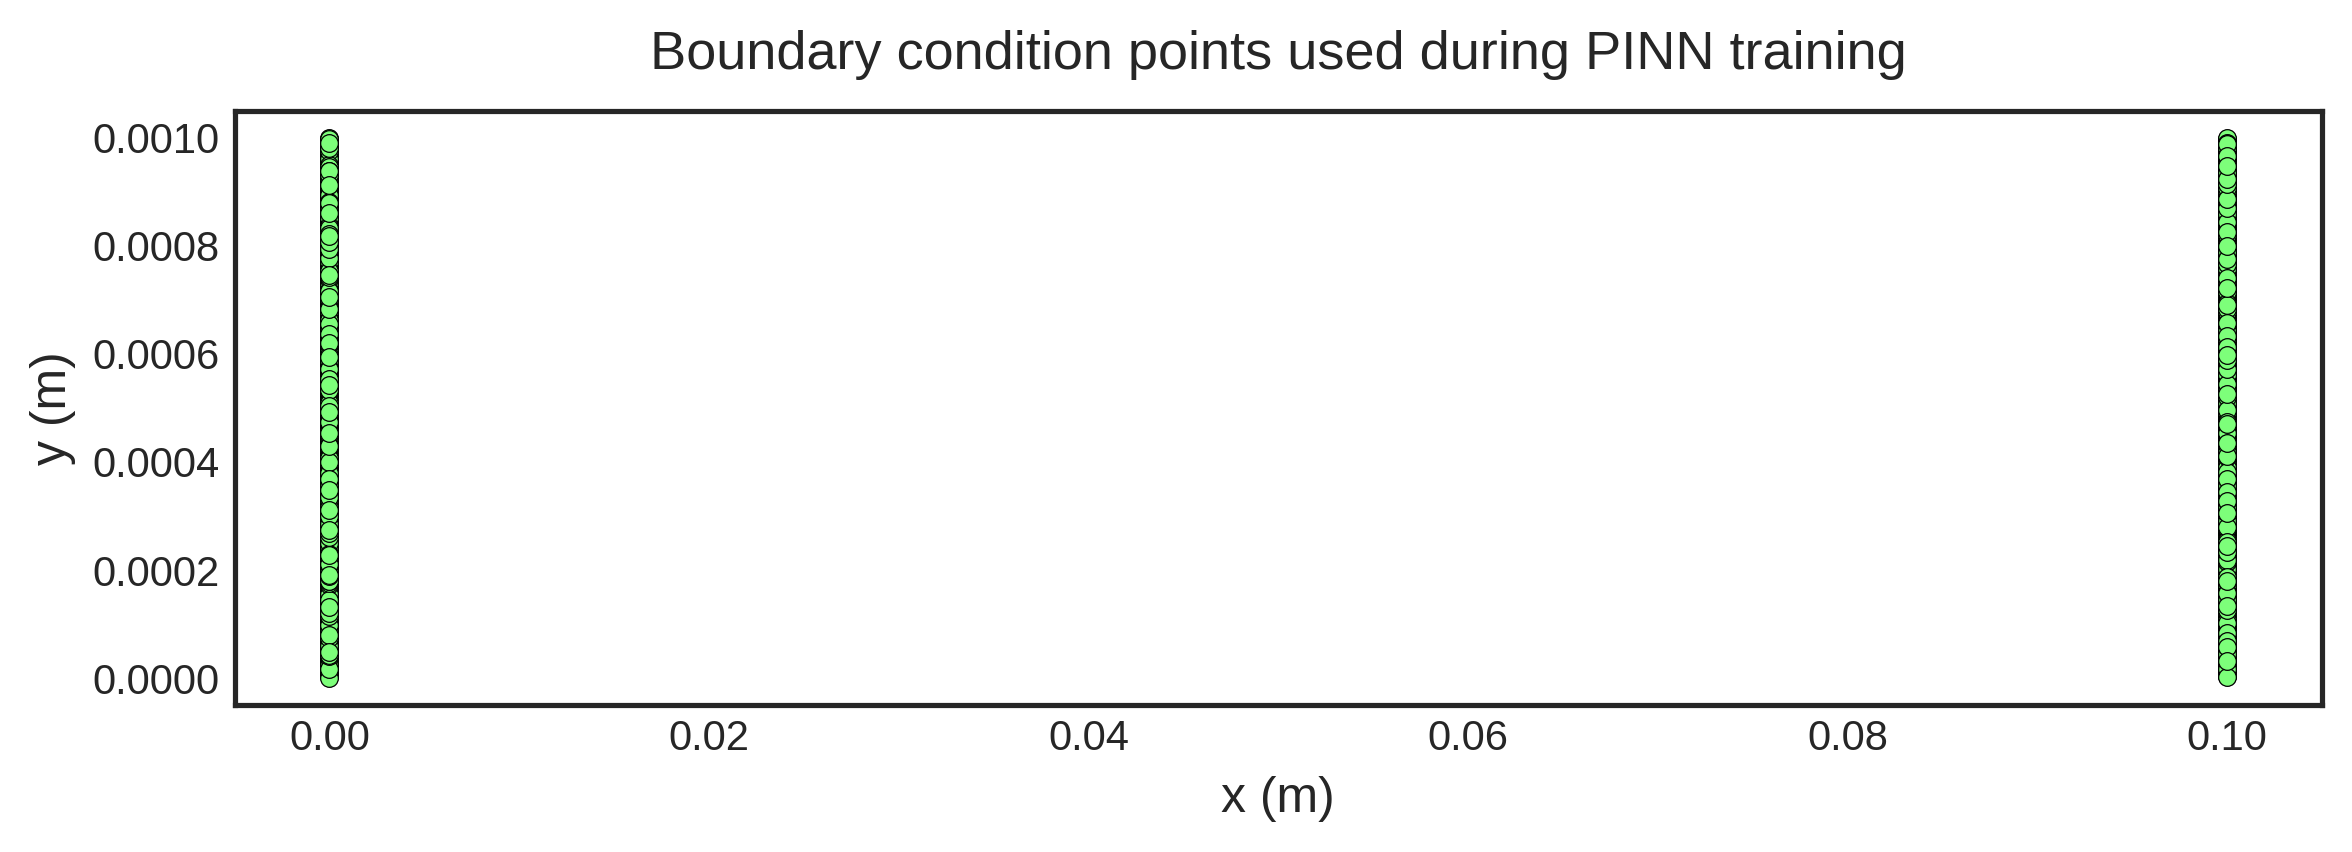

In [40]:
plt.figure(figsize=(8, 3))

# --- Estilo tipo PINN paper ---
plt.style.use('seaborn-v0_8-white')  # fondo blanco limpio
plt.scatter(xy_left[:, 0], xy_left[:, 1], c='#7dff7a', s=18, edgecolors='k', linewidths=0.3)
plt.scatter(xy_right[:, 0], xy_right[:, 1], c='#7dff7a', s=18, edgecolors='k', linewidths=0.3)
# plt.scatter(xy_top[:, 0], xy_top[:, 1], c='#7dff7a', s=18, edgecolors='k', linewidths=0.3)
# plt.scatter(xy_bottom[:, 0], xy_bottom[:, 1], c='#7dff7a', s=18, edgecolors='k', linewidths=0.3)


plt.xlabel('x (m)', fontsize=12)
plt.ylabel('y (m)', fontsize=12)
plt.title('Boundary condition points used during PINN training', fontsize=13, pad=10)

plt.grid(False)
plt.tight_layout()


plt.show()

In [41]:
x_electrical_bc, y_electrical_bc, x_mechanical_bc, y_mechanical_bc, x_right = create_beam_geom_BCs(n_points)

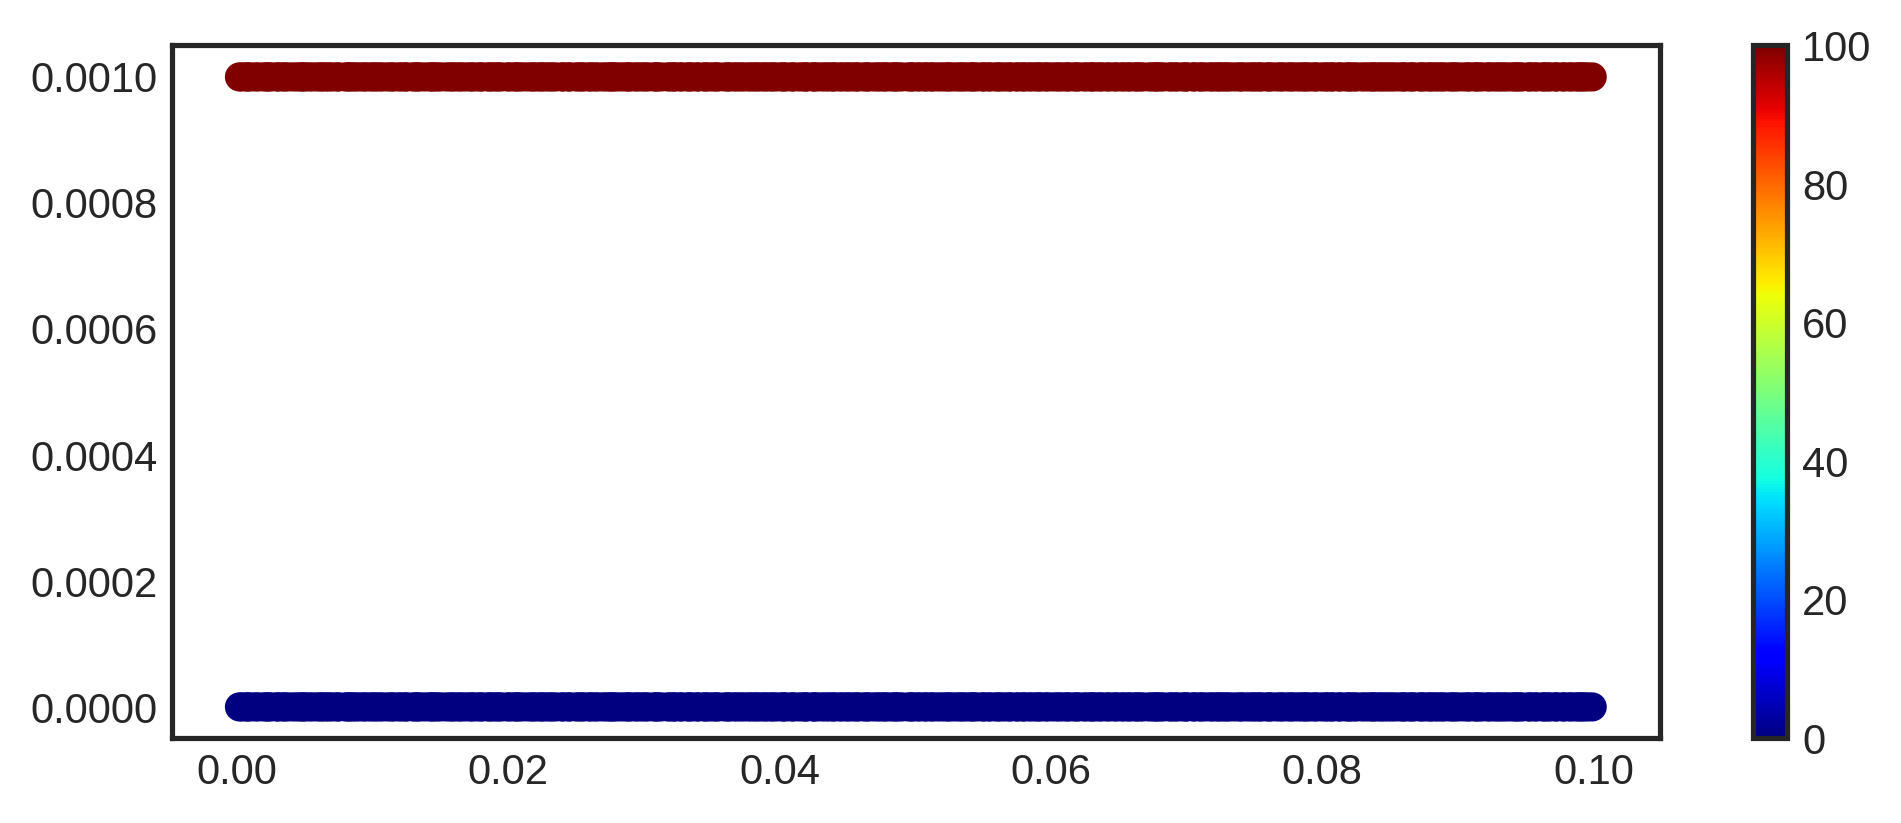

In [42]:
plt.figure(figsize=(8, 3))
plt.scatter(x_electrical_bc[:, 0], x_electrical_bc[:, 1], c=y_electrical_bc[:, 0], cmap='jet')
plt.colorbar()
plt.show()

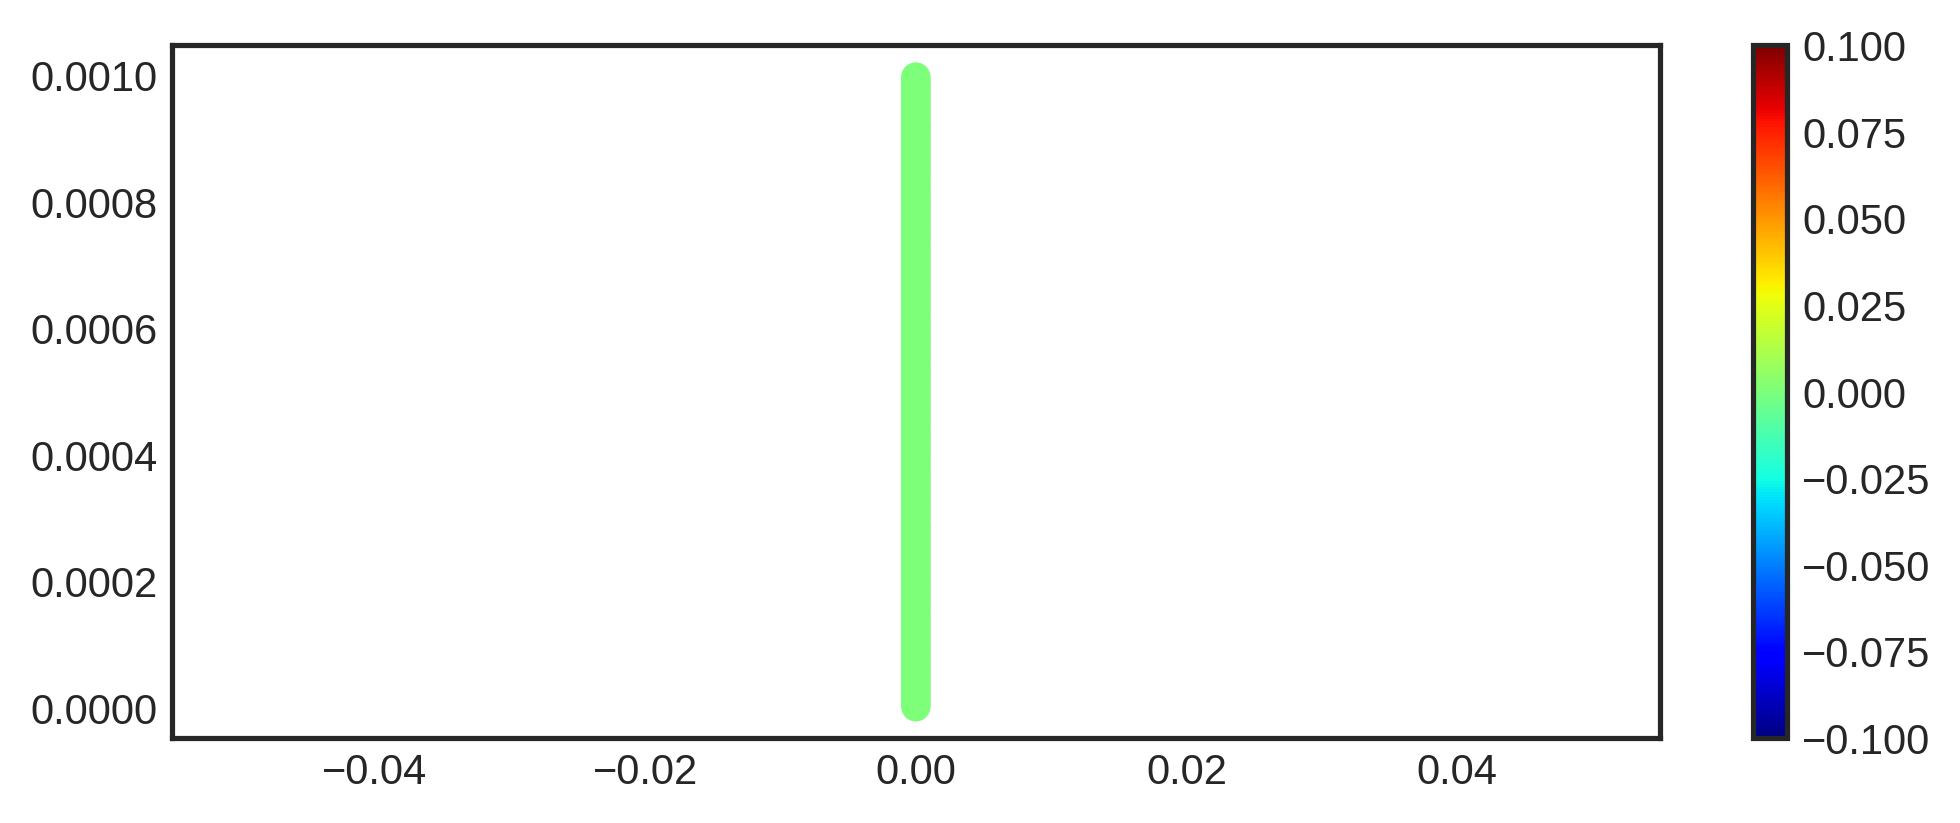

In [43]:
plt.figure(figsize=(8, 3))
plt.scatter(x_mechanical_bc[:, 0], x_mechanical_bc[:, 1], c=y_mechanical_bc[:,  1], cmap='jet')
plt.colorbar()
plt.show()

In [44]:
def get_collocation_points(n_points):
    sampler = qmc.LatinHypercube(d=2)
    sample = sampler.random(n=n_points)
    x = sample[:, 0] * WIDTH
    y = sample[:, 1] * (Y_TOP - Y_BOTTOM) + Y_BOTTOM
    # x = np.linspace(0, WIDTH, n_points)
    # y = np.linspace(0, HEIGHT, n_points)
    x.sort()
    y.sort()
    x, y = np.meshgrid(x, y)
    C11_array, C12_array, C22_array, G_array, epsilon1_array, epsilon2_array, e31_array, e33_array = get_coefficients(x, y)
    xy = np.hstack([x.flatten()[:, None], y.flatten()[:, None],
                    C11_array, C12_array, C22_array, G_array,
                    epsilon1_array, epsilon2_array, e31_array, e33_array])


    return xy

In [45]:
x_collocation = get_collocation_points(150)
np.random.shuffle(x_collocation)
x_collocation.shape

(22500, 10)

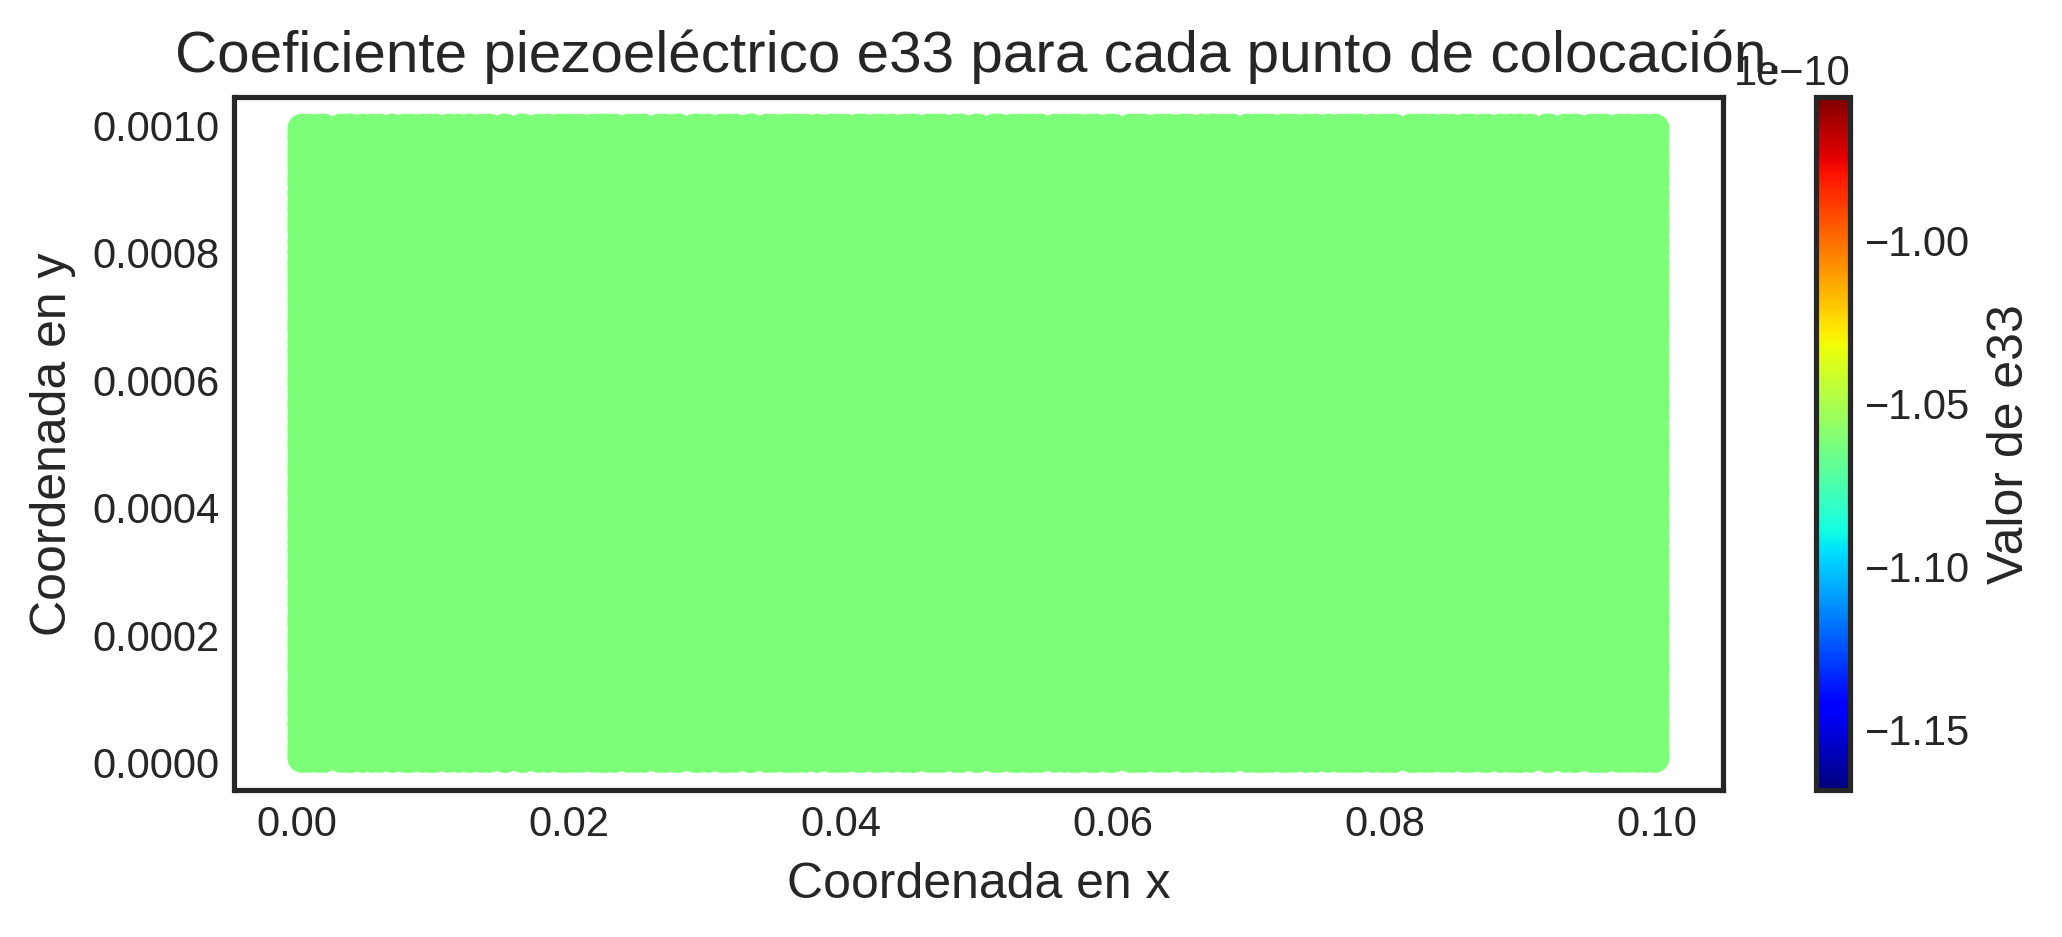

In [46]:
x_collocation_temp, coefficients = np.split(x_collocation, [2], axis=1)
plt.figure(figsize=(8, 3))
sc = plt.scatter(x_collocation[:, 0], x_collocation[:, 1], c=coefficients[:, 4], cmap='jet')
cbar = plt.colorbar(sc)
cbar.set_label('Valor de e33')  # Añadir etiqueta a la barra de color
plt.xlabel('Coordenada en x')
plt.ylabel('Coordenada en y')
plt.title('Coeficiente piezoeléctrico e33 para cada punto de colocación.')
plt.show()

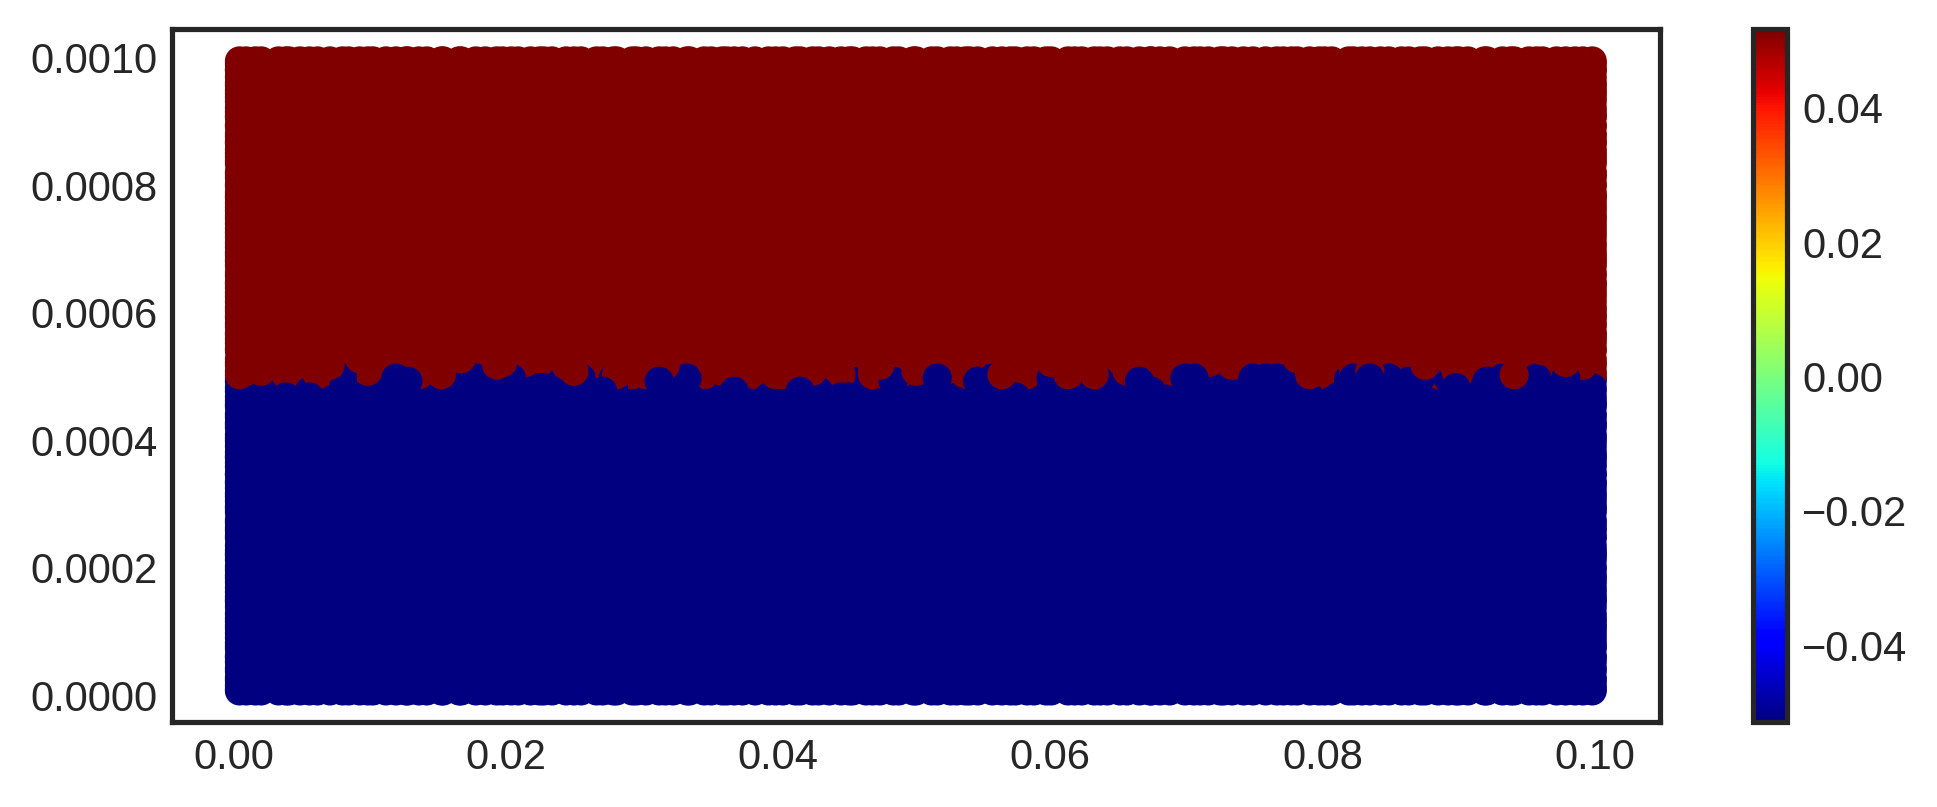

In [47]:

plt.figure(figsize=(8, 3))
plt.scatter(x_collocation[:, 0], x_collocation[:,1], c=x_collocation[:, 9], cmap='jet')
plt.colorbar()
plt.show()

In [48]:
x_collocation_test = get_collocation_points(200)

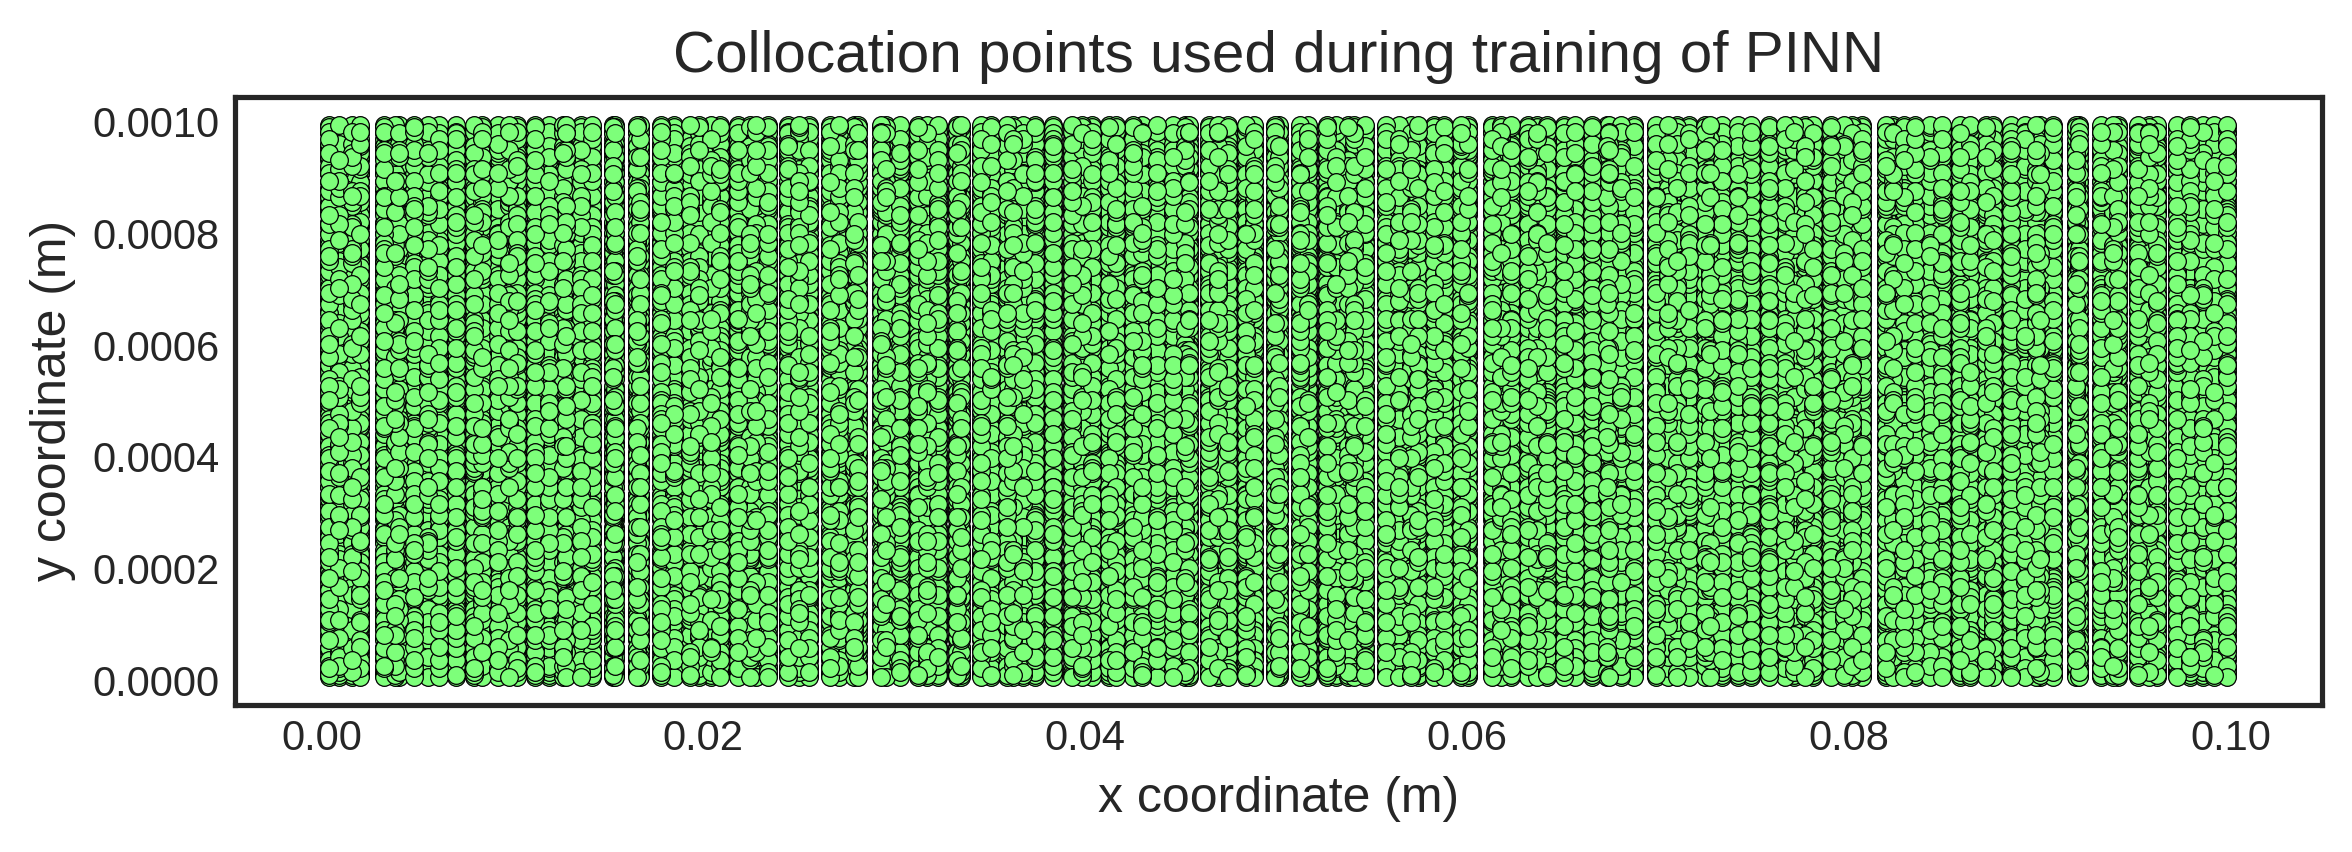

In [49]:
plt.figure(figsize=(8, 3))

# --- Estilo tipo PINN paper ---
plt.style.use('seaborn-v0_8-white')  # fondo blanco limpio
plt.scatter(x_collocation[:, 0], x_collocation[:,1], c='#7dff7a', s=18, edgecolors='k', linewidths=0.3)

plt.xlabel('x coordinate (m)')
plt.ylabel('y coordinate (m)')
plt.title('Collocation points used during training of PINN')

plt.grid(False)
plt.tight_layout()


plt.show()

In [50]:
np.max(x_collocation[:, 0]), np.max(x_collocation[:, 1])

(np.float64(0.09983097087903602), np.float64(0.0009943618395215417))

In [51]:
x_collocation_test.shape

(40000, 10)

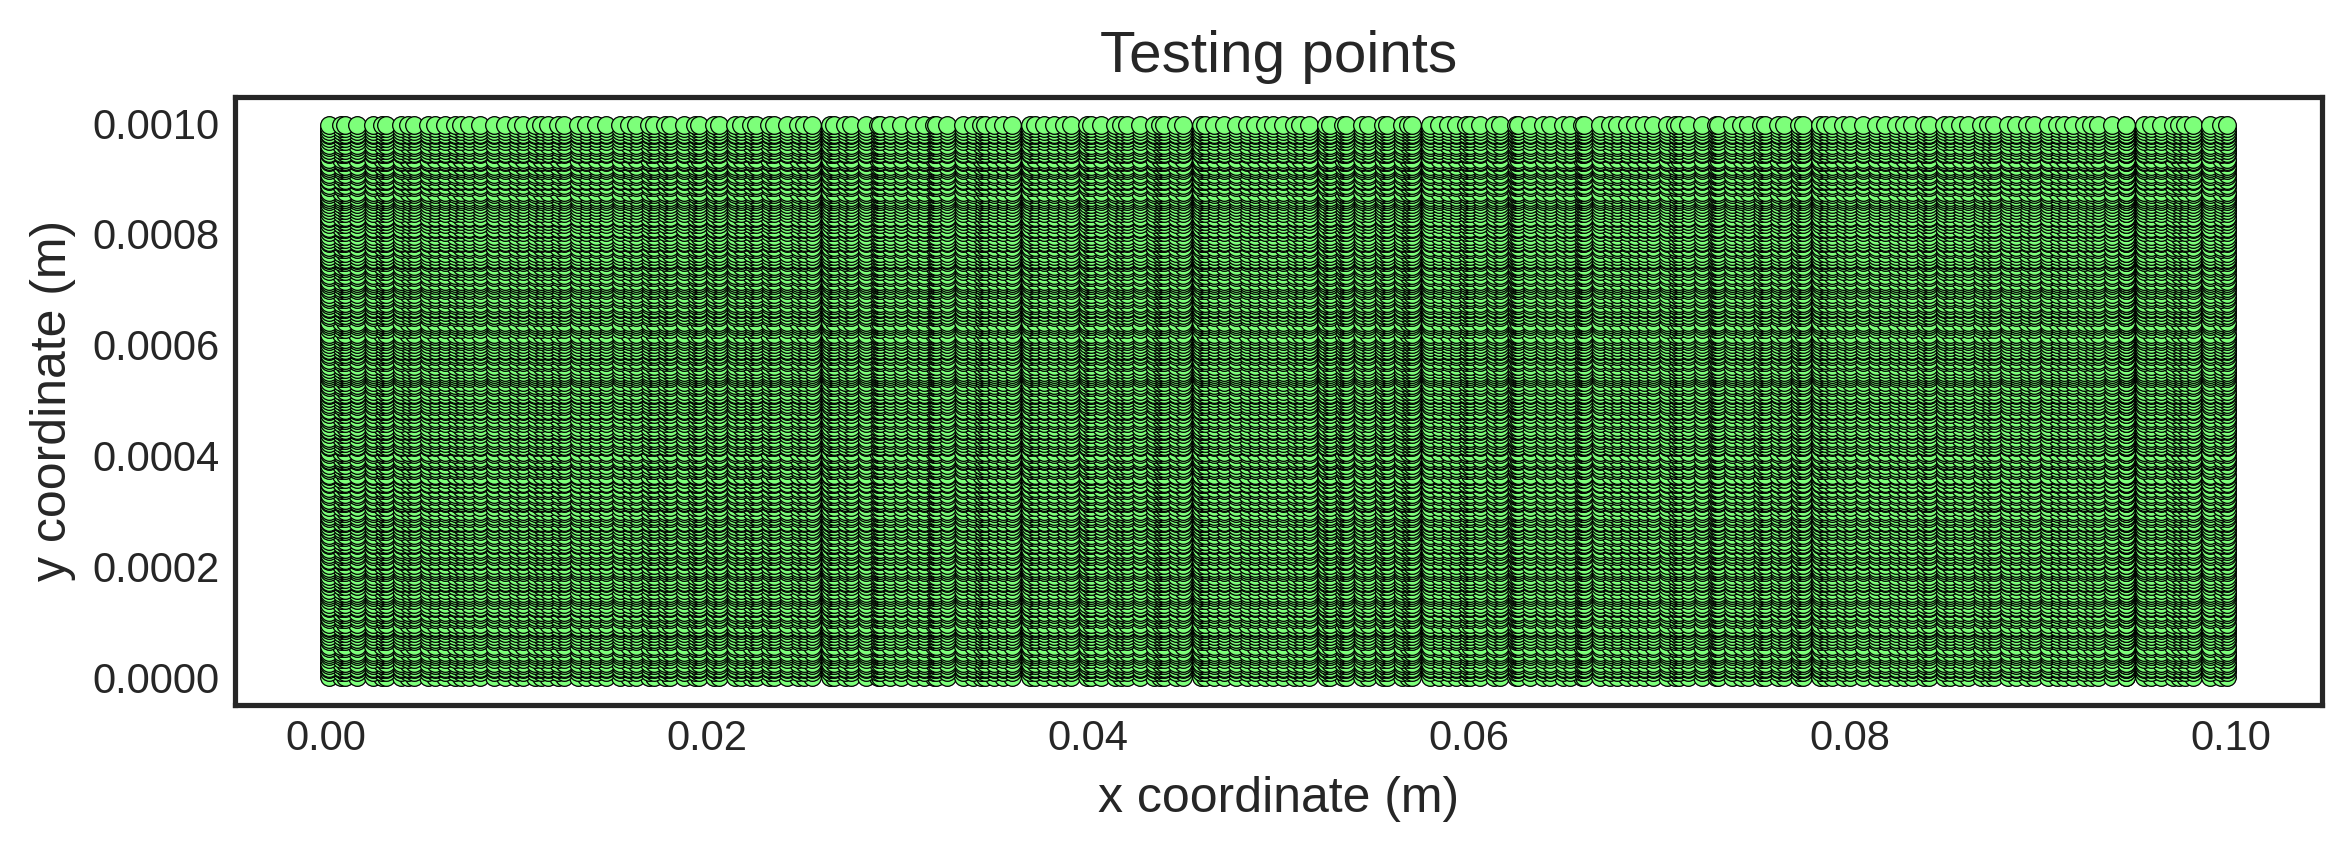

In [52]:
plt.figure(figsize=(8, 3))

# --- Estilo tipo PINN paper ---
plt.style.use('seaborn-v0_8-white')  # fondo blanco limpio
plt.scatter(x_collocation_test[:, 0], x_collocation_test[:,1], c='#7dff7a', s=18, edgecolors='k', linewidths=0.3)

plt.xlabel('x coordinate (m)')
plt.ylabel('y coordinate (m)')
plt.title('Testing points')

plt.grid(False)
plt.tight_layout()


plt.show()

In [ ]:
x_electrical_bc.shape, x_collocation.shape

((800, 2), (22500, 10))

In [ ]:
root = '/content/drive/MyDrive/PINN_piezo/'

In [ ]:
# np.save(root + 'x_electrical_bc.npy', x_electrical_bc)
# np.save(root + 'y_electrical_bc.npy', y_electrical_bc)
# np.save(root + 'x_mechanical_bc.npy', x_mechanical_bc)
# np.save(root + 'y_mechanical_bc.npy', y_mechanical_bc)
np.save(root + 'x_right.npy', x_right)
np.save(root + 'x_collocation_non_normalized_m1_d.npy', x_collocation)
np.save(root + 'x_collocation_test_non_normalized_m1_d.npy', x_collocation_test)
np.save(root + 'xy_top_non_normalized_m1_d.npy', xy_top)
np.save(root + 'xy_bottom_non_normalized_m1_d.npy', xy_bottom)
np.save(root + 'xy_left_non_normalized_m1_d.npy', xy_left)
np.save(root + 'xy_right_non_normalized_m1_d.npy', xy_right)